In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("Financial_Sample_Data - Sheet1.csv")

df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,Government,Germany,Carretera,NaN,"1,513.00",3,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014,NaN,NaN,NaN,NaN
1,Government,Germany,Paseo,NaN,"1,006.00",10,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014,NaN,NaN,Cards,charts
2,Government,Canada,Paseo,NaN,"1,725.00",10,350,"603,750.00",0.00,"603,750.00","448,500.00","155,250.00",1-Nov-13,11,November,2013,NaN,1.00,Total Gross Sales,Country wise sales
3,Government,Germany,Paseo,NaN,"1,513.00",10,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014,NaN,NaN,Total Profit,productwise profit
4,Government,Germany,Velo,NaN,"1,006.00",120,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014,NaN,NaN,Total Numbers of units sold,sales growth trend


In [2]:
df = df.drop(columns=df.columns[-4:])

In [3]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,"1,513.00",3,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,"1,006.00",10,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,"1,725.00",10,350,"603,750.00",0.00,"603,750.00","448,500.00","155,250.00",1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,"1,513.00",10,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,"1,006.00",120,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014


In [4]:
df['Discount Band'].value_counts()

Discount Band
High      245
Medium    242
Low       160
Name: count, dtype: int64

In [5]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null values:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (700, 16)

Column names:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    str    
 1   Country              700 non-null    str    
 2   Product              700 non-null    str    
 3   Discount Band        647 non-null    str    
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    int64  
 6   Sale Price           700 non-null    int64  
 7   Gross Sales          700 non-null    float64
 8   Discounts            700 non-null    float64
 9    Sales               700 non-null    float64
 10  COGS                 700

In [6]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print(df.columns.tolist())

['segment', 'country', 'product', 'discount_band', 'units_sold', 'manufacturing_price', 'sale_price', 'gross_sales', 'discounts', 'sales', 'cogs', 'profit', 'date', 'month_number', 'month_name', 'year']


In [7]:
df[df["discount_band"].isna()].head()

,segment,country,product,discount_band,units_sold,manufacturing_price,sale_price,gross_sales,discounts,sales,cogs,profit,date,month_number,month_name,year
0,Government,Germany,Carretera,NaN,"1,513.00",3,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014
1,Government,Germany,Paseo,NaN,"1,006.00",10,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014
2,Government,Canada,Paseo,NaN,"1,725.00",10,350,"603,750.00",0.00,"603,750.00","448,500.00","155,250.00",1-Nov-13,11,November,2013
3,Government,Germany,Paseo,NaN,"1,513.00",10,350,"529,550.00",0.00,"529,550.00","393,380.00","136,170.00",1-Dec-14,12,December,2014
4,Government,Germany,Velo,NaN,"1,006.00",120,350,"352,100.00",0.00,"352,100.00","261,560.00","90,540.00",1-Jun-14,6,June,2014


In [8]:
print(df["discount_band"].unique())

<StringArray>
[nan, 'Low', 'Medium', 'High']
Length: 4, dtype: str


In [11]:
df.loc[
    df["discount_band"].isna(),
    ["discount_band","discounts"]
].head(10)

,discount_band,discounts


In [12]:
df["discount_band"] = df["discount_band"].fillna("No Discount")

In [14]:
df.groupby("discount_band")["discounts"].agg(
    records="count",
    total_discount="sum",
    minimum_discount="min",
    maximum_discount="max"
)

,records,total_discount,minimum_discount,maximum_discount
discount_band,,,,
High,245,"5,317,026.28",274.40,"149,677.50"
Low,160,"885,675.80",18.41,"48,300.00"
Medium,242,"3,002,546.17",110.46,"102,667.50"
No Discount,53,0.00,0.00,0.00


#Segment Performance Analysis:-

In [16]:
segment_performance = (
    df.groupby("segment", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_units_sold=("units_sold", "sum"),
          total_discounts=("discounts", "sum"),
          total_cogs=("cogs", "sum")
      )
)

segment_performance["profit_margin_pct"] = (
    segment_performance["total_profit"] /
    segment_performance["total_sales"] * 100
)

segment_performance["discount_rate_pct"] = (
    segment_performance["total_discounts"] /
    (segment_performance["total_sales"] + segment_performance["total_discounts"]) * 100
)

segment_performance = segment_performance.sort_values(
    by="total_profit",
    ascending=False
)

segment_performance = segment_performance.round(2)

segment_performance

,segment,total_sales,total_profit,total_units_sold,total_discounts,total_cogs,profit_margin_pct,discount_rate_pct
2,Government,"52,504,260.67","11,388,173.17","470,673.50","3,898,805.83","41,116,087.50",21.69,6.91
4,Small Business,"42,427,918.50","4,143,168.50","153,139.00","3,513,781.50","38,284,750.00",9.77,7.65
0,Channel Partners,"1,800,593.64","1,316,803.14","161,263.50","134,568.36","483,790.50",73.13,6.95
3,Midmarket,"2,381,883.08","660,103.07","172,178.00","200,786.92","1,721,780.00",27.71,7.77
1,Enterprise,"19,611,694.38","-614,545.62","168,552.00","1,457,305.62","20,226,240.00",-3.13,6.92


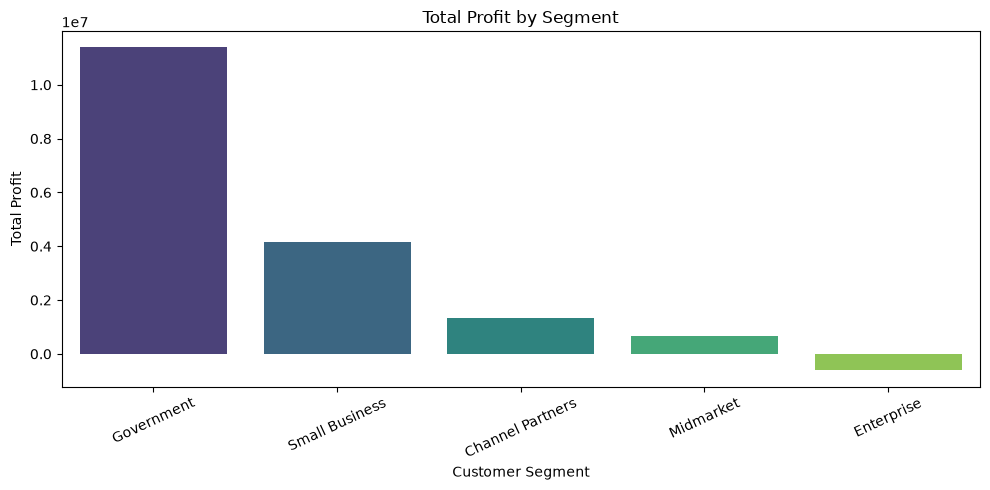

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_performance,
    x="segment",
    y="total_profit",
    hue="segment",
    legend=False,
    palette="viridis"
)

plt.title("Total Profit by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [21]:
segment_performance.sort_values(
    by="profit_margin_pct",
    ascending=True
)[[
    "segment",
    "total_sales",
    "total_profit",
    "total_cogs",
    "total_discounts",
    "profit_margin_pct",
    "discount_rate_pct"
]]

,segment,total_sales,total_profit,total_cogs,total_discounts,profit_margin_pct,discount_rate_pct
1,Enterprise,"19,611,694.38","-614,545.62","20,226,240.00","1,457,305.62",-3.13,6.92
4,Small Business,"42,427,918.50","4,143,168.50","38,284,750.00","3,513,781.50",9.77,7.65
2,Government,"52,504,260.67","11,388,173.17","41,116,087.50","3,898,805.83",21.69,6.91
3,Midmarket,"2,381,883.08","660,103.07","1,721,780.00","200,786.92",27.71,7.77
0,Channel Partners,"1,800,593.64","1,316,803.14","483,790.50","134,568.36",73.13,6.95


#Country Performance Analysis:-

In [22]:
country_performance = (
    df.groupby("country", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_units_sold=("units_sold", "sum"),
          total_discounts=("discounts", "sum"),
          total_cogs=("cogs", "sum")
      )
)

country_performance["profit_margin_pct"] = (
    country_performance["total_profit"] /
    country_performance["total_sales"] * 100
)

country_performance["discount_rate_pct"] = (
    country_performance["total_discounts"] /
    (country_performance["total_sales"] + country_performance["total_discounts"]) * 100
)

country_performance = (
    country_performance
      .sort_values("total_profit", ascending=False)
      .round(2)
)

country_performance

,country,total_sales,total_profit,total_units_sold,total_discounts,total_cogs,profit_margin_pct,discount_rate_pct
1,France,"24,354,172.28","3,781,020.78","240,931.00","1,727,502.22","20,573,151.50",15.53,6.62
2,Germany,"23,505,340.82","3,680,388.82","201,494.00","1,416,126.68","19,824,952.00",15.66,5.68
0,Canada,"24,887,654.88","3,529,228.88","247,428.50","2,044,508.62","21,358,426.00",14.18,7.59
4,United States of America,"25,029,830.16","2,995,540.66","232,627.50","2,239,527.84","22,034,289.50",11.97,8.21
3,Mexico,"20,949,352.11","2,907,523.11","203,325.00","1,777,582.89","18,041,829.00",13.88,7.82


#Product Performance Analysis:-


In [23]:
product_performance = (
    df.groupby("product", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_units_sold=("units_sold", "sum"),
          total_discounts=("discounts", "sum"),
          total_cogs=("cogs", "sum"),
          avg_sale_price=("sale_price", "mean")
      )
)

product_performance["profit_margin_pct"] = (
    product_performance["total_profit"] /
    product_performance["total_sales"] * 100
)

product_performance["discount_rate_pct"] = (
    product_performance["total_discounts"] /
    (product_performance["total_sales"] + product_performance["total_discounts"]) * 100
)

product_performance = (
    product_performance
      .sort_values("total_profit", ascending=False)
      .round(2)
)

product_performance

,product,total_sales,total_profit,total_units_sold,total_discounts,total_cogs,avg_sale_price,profit_margin_pct,discount_rate_pct
3,Paseo,"33,011,143.95","4,797,437.95","338,239.50","2,600,518.05","28,213,706.00",108.18,14.53,7.30
4,VTT,"20,511,921.02","3,034,608.02","168,783.00","1,456,612.48","17,477,313.00",138.59,14.79,6.63
0,Amarilla,"17,747,116.06","2,814,104.06","155,315.00","1,290,163.44","14,933,012.00",128.68,15.86,6.78
5,Velo,"18,250,059.46","2,305,992.46","162,424.50","1,576,709.04","15,944,067.00",115.24,12.64,7.95
2,Montana,"15,390,801.88","2,114,754.88","154,198.00","1,159,032.62","13,276,047.00",117.10,13.74,7.00
1,Carretera,"13,815,307.88","1,826,804.88","146,846.00","1,122,212.62","11,988,503.00",111.77,13.22,7.51


#Discount Impact Analysis

In [24]:
discount_performance = (
    df.groupby("discount_band", as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          gross_sales=("gross_sales", "sum"),
          total_discounts=("discounts", "sum"),
          total_profit=("profit", "sum"),
          total_units_sold=("units_sold", "sum"),
          total_cogs=("cogs", "sum")
      )
)

discount_performance["profit_margin_pct"] = (
    discount_performance["total_profit"] /
    discount_performance["total_sales"] * 100
)

discount_performance["discount_rate_pct"] = (
    discount_performance["total_discounts"] /
    discount_performance["gross_sales"] * 100
)

discount_performance = (
    discount_performance
      .sort_values("total_profit", ascending=False)
      .round(2)
)

discount_performance

,discount_band,total_sales,gross_sales,total_discounts,total_profit,total_units_sold,total_cogs,profit_margin_pct,discount_rate_pct
1,Low,"34,629,778.70","35,515,454.50","885,675.80","6,188,857.70","261,858.50","28,440,921.00",17.87,2.49
2,Medium,"38,780,430.84","41,782,977.00","3,002,546.16","5,579,522.84","379,698.50","33,200,908.00",14.39,7.19
0,High,"37,372,486.72","42,689,513.00","5,317,026.28","3,388,866.72","398,085.50","33,983,620.00",9.07,12.46
3,No Discount,"7,943,654.00","7,943,654.00",0.00,"1,736,455.00","86,163.50","6,207,199.00",21.86,0.00


#Segment Vs Product Analysis

In [25]:
segment_product_performance = (
    df.groupby(["segment", "product"], as_index=False)
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_units_sold=("units_sold", "sum"),
          total_discounts=("discounts", "sum"),
          total_cogs=("cogs", "sum")
      )
)

segment_product_performance["profit_margin_pct"] = (
    segment_product_performance["total_profit"] /
    segment_product_performance["total_sales"] * 100
)

segment_product_performance = segment_product_performance.round(2)

top_10_combinations = (
    segment_product_performance
      .sort_values("total_profit", ascending=False)
      .head(10)
)

bottom_10_combinations = (
    segment_product_performance
      .sort_values("total_profit", ascending=True)
      .head(10)
)

print("Top 10 Segment–Product Combinations by Profit")
display(top_10_combinations)

print("\nBottom 10 Segment–Product Combinations by Profit")
display(bottom_10_combinations)

Top 10 Segment–Product Combinations by Profit


,segment,product,total_sales,total_profit,total_units_sold,total_discounts,total_cogs,profit_margin_pct
15,Government,Paseo,"14,882,230.70","3,057,290.70","146,798.50","1,371,742.30","11,824,940.00",20.54
12,Government,Amarilla,"9,942,899.11","2,208,301.61","68,044.50","589,187.39","7,734,597.50",22.21
16,Government,VTT,"8,235,828.71","1,840,653.71","64,098.50","514,395.29","6,395,175.00",22.35
17,Government,Velo,"7,813,422.05","1,756,732.05","72,163.50","533,950.95","6,056,690.00",22.48
13,Government,Carretera,"6,080,944.08","1,398,994.08","54,911.50","349,856.92","4,681,950.00",23.01
27,Small Business,Paseo,"11,498,809.50","1,231,309.50","41,070.00","822,190.50","10,267,500.00",10.71
14,Government,Montana,"5,548,936.02","1,126,201.02","64,657.00","539,672.98","4,422,735.00",20.30
28,Small Business,VTT,"9,341,400.00","982,150.00","33,437.00","689,700.00","8,359,250.00",10.51
26,Small Business,Montana,"6,674,938.50","743,313.50","23,726.50","443,011.50","5,931,625.00",11.14
29,Small Business,Velo,"6,407,977.50","431,102.50","23,907.50","764,272.50","5,976,875.00",6.73



Bottom 10 Segment–Product Combinations by Profit


,segment,product,total_sales,total_profit,total_units_sold,total_discounts,total_cogs,profit_margin_pct
7,Enterprise,Carretera,"3,203,708.12","-222,711.88","28,553.50","365,479.38","3,426,420.00",-6.95
10,Enterprise,VTT,"2,300,437.50","-99,082.50","19,996.00","199,062.50","2,399,520.00",-4.31
6,Enterprise,Amarilla,"2,643,607.50","-95,152.50","22,823.00","209,267.50","2,738,760.00",-3.60
11,Enterprise,Velo,"3,581,237.50","-84,762.50","30,550.00","237,512.50","3,666,000.00",-2.37
9,Enterprise,Paseo,"5,267,860.00","-81,740.00","44,580.00","304,640.00","5,349,600.00",-1.55
8,Enterprise,Montana,"2,614,843.75","-31,096.25","22,049.50","141,343.75","2,645,940.00",-1.19
18,Midmarket,Amarilla,"248,685.45","63,605.45","18,508.00","28,934.55","185,080.00",25.58
23,Midmarket,Velo,"264,498.38","68,653.38","19,584.50","29,269.12","195,845.00",25.96
20,Midmarket,Montana,"290,239.05","83,879.05","20,636.00","19,300.95","206,360.00",28.90
22,Midmarket,VTT,"333,425.85","91,120.85","24,230.50","30,031.65","242,305.00",27.33


#inspect the loss-making Enterprise–Carretera records in detail

In [27]:
enterprise_carretera = df[
    (df["segment"] == "Enterprise") &
    (df["product"] == "Carretera")
]

enterprise_carretera[[
    "segment",
    "country",
    "product",
    "discount_band",
    "units_sold",
    "sale_price",
    "gross_sales",
    "discounts",
    "sales",
    "cogs",
    "profit"
]].sort_values("profit").head(10)

,segment,country,product,discount_band,units_sold,sale_price,gross_sales,discounts,sales,cogs,profit
570,Enterprise,Germany,Carretera,High,"2,767.00",125,"345,875.00","51,881.25","293,993.75","332,040.00","-38,046.25"
553,Enterprise,Mexico,Carretera,High,"2,821.00",125,"352,625.00","49,367.50","303,257.50","338,520.00","-35,262.50"
478,Enterprise,United States of America,Carretera,High,"3,445.50",125,"430,687.50","43,068.75","387,618.75","413,460.00","-25,841.25"
519,Enterprise,Canada,Carretera,High,"2,416.00",125,"302,000.00","36,240.00","265,760.00","289,920.00","-24,160.00"
520,Enterprise,Mexico,Carretera,High,"2,156.00",125,"269,500.00","32,340.00","237,160.00","258,720.00","-21,560.00"
509,Enterprise,France,Carretera,High,"2,441.00",125,"305,125.00","33,563.75","271,561.25","292,920.00","-21,358.75"
569,Enterprise,France,Carretera,High,"1,174.00",125,"146,750.00","22,012.50","124,737.50","140,880.00","-16,142.50"
571,Enterprise,Germany,Carretera,High,"1,085.00",125,"135,625.00","20,343.75","115,281.25","130,200.00","-14,918.75"
548,Enterprise,France,Carretera,High,"1,023.00",125,"127,875.00","17,902.50","109,972.50","122,760.00","-12,787.50"
479,Enterprise,France,Carretera,High,"1,482.00",125,"185,250.00","18,525.00","166,725.00","177,840.00","-11,115.00"


In [29]:
enterprise_carretera_summary = enterprise_carretera.agg(
    transactions=("profit", "count"),
    total_sales=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_cogs=("cogs", "sum"),
    total_discounts=("discounts", "sum"),
    total_units_sold=("units_sold", "sum"),
    avg_sale_price=("sale_price", "mean")
)

enterprise_carretera_summary

,profit,sales,cogs,discounts,units_sold,sale_price
transactions,15.00,NaN,NaN,NaN,NaN,NaN
total_sales,NaN,"3,203,708.12",NaN,NaN,NaN,NaN
total_profit,"-222,711.88",NaN,NaN,NaN,NaN,NaN
total_cogs,NaN,NaN,"3,426,420.00",NaN,NaN,NaN
total_discounts,NaN,NaN,NaN,"365,479.38",NaN,NaN
total_units_sold,NaN,NaN,NaN,NaN,"28,553.50",NaN
avg_sale_price,NaN,NaN,NaN,NaN,NaN,125.00


#Verifying Does Every Sale with Enterprise-Carretera combination was a loss

In [30]:
enterprise_carretera = df[
    (df["segment"] == "Enterprise") &
    (df["product"] == "Carretera")
]

print("Total transactions:", len(enterprise_carretera))
print("Profit-making transactions:", (enterprise_carretera["profit"] > 0).sum())
print("Loss-making transactions:", (enterprise_carretera["profit"] < 0).sum())
print("Break-even transactions:", (enterprise_carretera["profit"] == 0).sum())

print("\nHighest profit in this combination:")
print(enterprise_carretera["profit"].max())

print("\nLowest profit in this combination:")
print(enterprise_carretera["profit"].min())

Total transactions: 15
Profit-making transactions: 3
Loss-making transactions: 12
Break-even transactions: 0

Highest profit in this combination:
5304.375

Lowest profit in this combination:
-38046.25


#Visualization Part :-  Creating four charts

1.Profit By Segment

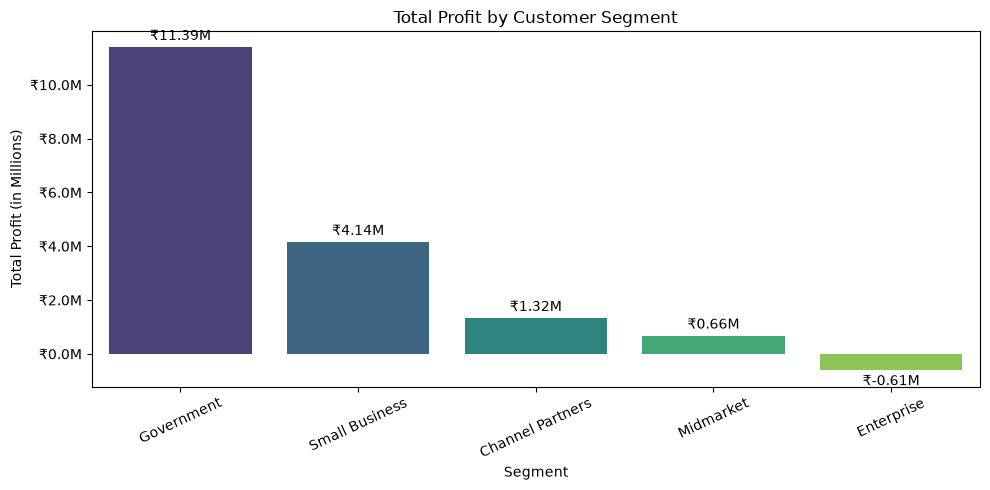

In [47]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 5))

# Creating a barplot and assigning it to an Axes object (ax)
ax = sns.barplot(
    data=segment_performance,
    x="segment",
    y="total_profit",
    hue="segment",
    legend=False,
    palette="viridis",
)

# Adding data labels above each bar formatted in Millions

for container in ax.containers:
  labels = [f"₹{val / 1e6:.2f}M" for val in container.datavalues]
  ax.bar_label(container, labels=labels, padding=3)

# Formatting Y-axis display units in Millions

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M"))

plt.title("Total Profit by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit (in Millions)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

2. Net Sales vs Profit by Country

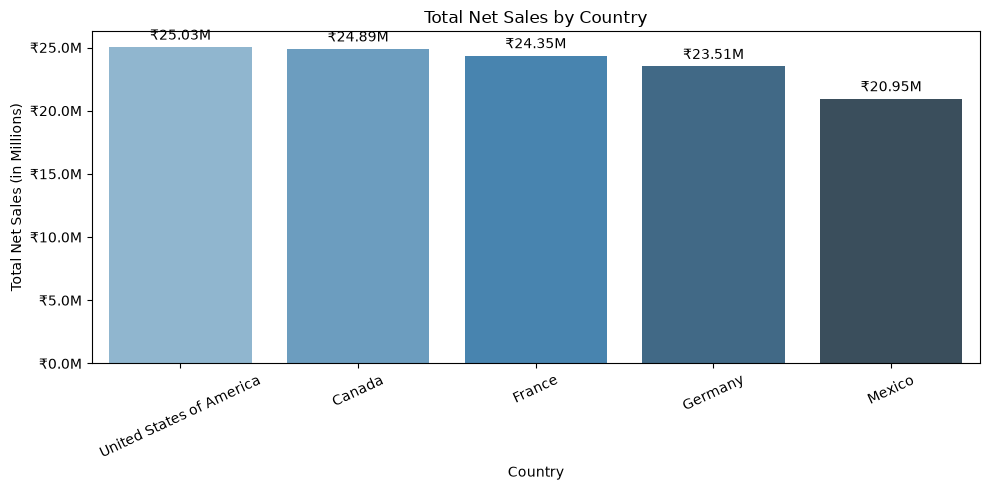

In [46]:
country_chart = country_performance.sort_values("total_sales", ascending=False)

plt.figure(figsize=(10, 5))

# creating a barplot and assigning it to an Axes object (ax)
ax = sns.barplot(
    data=country_chart,
    x="country",
    y="total_sales",
    hue="country",
    legend=False,
    palette="Blues_d",
)

# Adding data labels above each bar formatted in Millions

for container in ax.containers:
  labels = [f"₹{val / 1e6:.2f}M" for val in container.datavalues]
  ax.bar_label(container, labels=labels, padding=3)

# Formatting Y-axis display units in Millions

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M"))

plt.title("Total Net Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Net Sales (in Millions)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

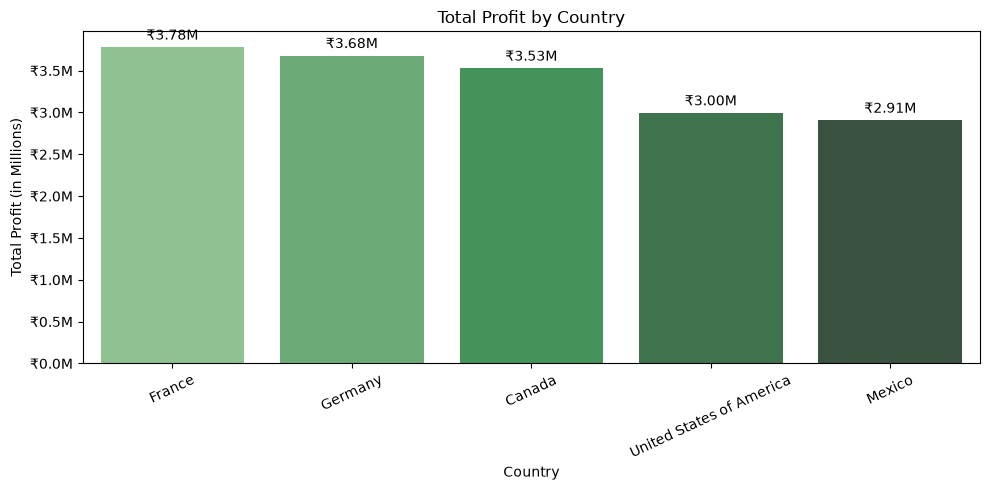

In [45]:
plt.figure(figsize=(10, 5))

# Creating a barplot and assigning it to an Axes object (ax)

ax = sns.barplot(
    data=country_performance,
    x="country",
    y="total_profit",
    hue="country",
    legend=False,
    palette="Greens_d",
)

#  Adding data labels above each bar formatted in Millions

for container in ax.containers:
  labels = [f"₹{val / 1e6:.2f}M" for val in container.datavalues]
  ax.bar_label(container, labels=labels, padding=3)

# Formatting Y-axis display units in Millions

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M"))

plt.title("Total Profit by Country")
plt.xlabel("Country")
plt.ylabel("Total Profit (in Millions)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

3. Product Profitability

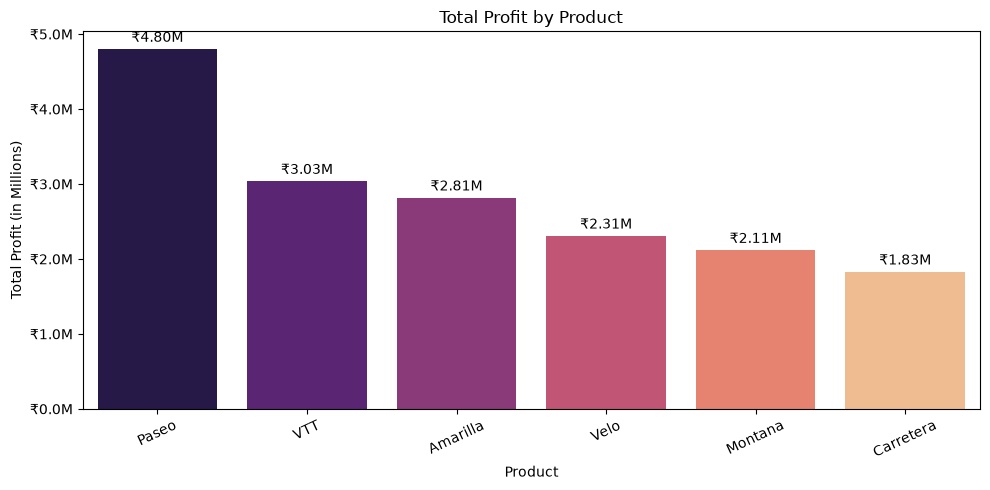

In [44]:


product_chart = product_performance.sort_values("total_profit", ascending=False)

plt.figure(figsize=(10, 5))

# Creating a barplot and assigning it to an Axes object (ax)
ax = sns.barplot(
    data=product_chart,
    x="product",
    y="total_profit",
    hue="product",
    legend=False,
    palette="magma",
)

# Adding data labels and Display units in Millions

for container in ax.containers:
  labels = [f"₹{val / 1e6:.2f}M" for val in container.datavalues]
  ax.bar_label(container, labels=labels, padding=3)

# Formatting Y-axis display units in Millions

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"₹{x/1e6:.1f}M"))

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit (in Millions)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

4. Discount Vs Profit Margin

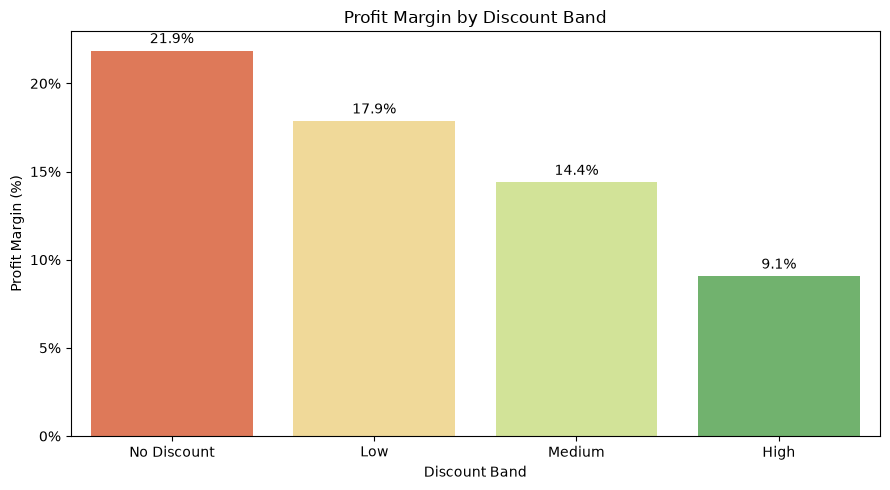

In [41]:


discount_order = ["No Discount", "Low", "Medium", "High"]

discount_chart = discount_performance.copy()

discount_chart["discount_band"] = pd.Categorical(
    discount_chart["discount_band"], categories=discount_order, ordered=True
)

discount_chart = discount_chart.sort_values("discount_band")

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=discount_chart,
    x="discount_band",
    y="profit_margin_pct",
    hue="discount_band",
    dodge=False,  # Fixes the shifted/off-center bars
    legend=False,
    palette="RdYlGn",
)

# Add data labels above each bar
for container in ax.containers:
  labels = [f"{val:.1f}%" for val in container.datavalues]
  ax.bar_label(container, labels=labels, padding=3)

# Format Y-axis tick labels as percentages
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:.0f}%"))

plt.title("Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.show()

#Downloading tables as output for Excel


In [43]:
with pd.ExcelWriter("financial_sales_analysis_output.xlsx") as writer:
    segment_performance.to_excel(
        writer,
        sheet_name="Segment Analysis",
        index=False
    )

    country_performance.to_excel(
        writer,
        sheet_name="Country Analysis",
        index=False
    )

    product_performance.to_excel(
        writer,
        sheet_name="Product Analysis",
        index=False
    )

    discount_performance.to_excel(
        writer,
        sheet_name="Discount Analysis",
        index=False
    )

    segment_product_performance.to_excel(
        writer,
        sheet_name="Segment Product Analysis",
        index=False
    )

    enterprise_carretera.to_excel(
        writer,
        sheet_name="Enterprise Carretera Detail",
        index=False
    )

print("Excel analysis file created successfully.")

Excel analysis file created successfully.
